# vLLM Config Sweep on Colab T4

Results from running vLLM 0.30.0 on a Tesla T4 serving
`Qwen/Qwen2.5-0.5B-Instruct`. Swept `max_num_seqs ∈ {8, 32}` at
concurrency 1, 4, 16.

The int4 (AWQ) configurations produced zero completed requests — the
AWQ model repo lacks a chat template and the benchmark fell through to
a 404 endpoint. See the README section for details.

Numbers come from `04_serving_benchmarks/results.csv`, produced by
`parse_results.py` from the raw JSONs in `04_serving_benchmarks/results/`.

Reproduce:

    uv run 04_serving_benchmarks/parse_results.py

In [1]:
import pandas as pd

df = pd.read_csv("../04_serving_benchmarks/results.csv")
df[["config", "concurrency", "output_throughput_tps",
    "ttft_p50_ms", "ttft_p99_ms", "e2e_p99_ms", "completed"]]

,config,concurrency,output_throughput_tps,ttft_p50_ms,ttft_p99_ms,e2e_p99_ms,completed
0,fp16_mns32,1,156.430775,35.046536,64.529962,851.612330,100
1,fp16_mns32,16,901.122554,121.532800,3343.494838,4481.290893,100
2,fp16_mns32,4,523.370400,47.087729,3477.259144,4302.309701,100
3,fp16_mns8,1,162.189031,34.409900,58.764440,815.948643,100
4,fp16_mns8,16,1031.875728,1010.078466,1103.679942,2017.402728,100
5,fp16_mns8,4,544.869060,55.437493,2781.372815,3618.951839,100
6,int4_mns32,1,0.000000,0.000000,0.000000,0.000000,0
7,int4_mns32,16,0.000000,0.000000,0.000000,0.000000,0
8,int4_mns32,4,0.000000,0.000000,0.000000,0.000000,0
9,int4_mns8,1,0.000000,0.000000,0.000000,0.000000,0


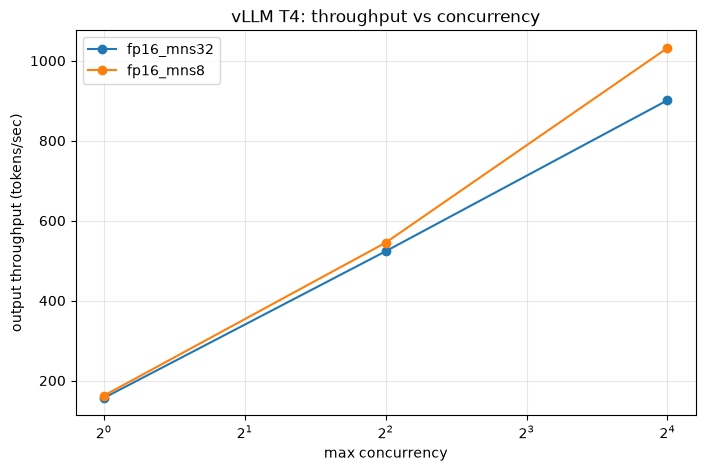

In [2]:
import matplotlib.pyplot as plt

df_ok = df[df["completed"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
for cfg in sorted(df_ok["config"].unique()):
    sub = df_ok[df_ok["config"] == cfg].sort_values("concurrency")
    ax.plot(sub["concurrency"], sub["output_throughput_tps"],
            "o-", label=cfg)
ax.set_xlabel("max concurrency")
ax.set_ylabel("output throughput (tokens/sec)")
ax.set_title("vLLM T4: throughput vs concurrency")
ax.set_xscale("log", base=2)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

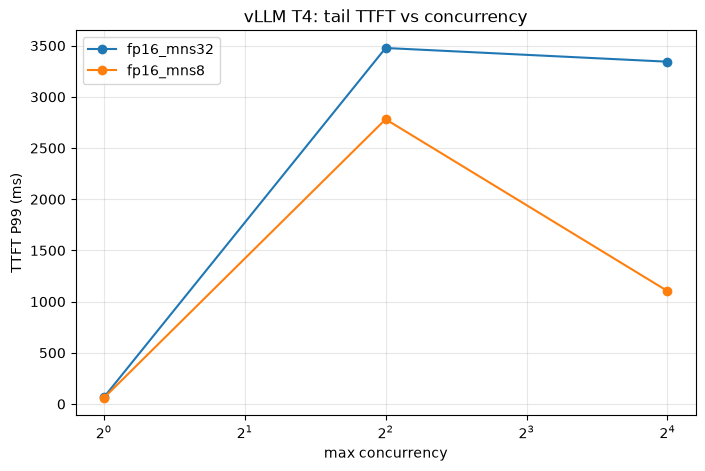

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for cfg in sorted(df_ok["config"].unique()):
    sub = df_ok[df_ok["config"] == cfg].sort_values("concurrency")
    ax.plot(sub["concurrency"], sub["ttft_p99_ms"],
            "o-", label=cfg)
ax.set_xlabel("max concurrency")
ax.set_ylabel("TTFT P99 (ms)")
ax.set_title("vLLM T4: tail TTFT vs concurrency")
ax.set_xscale("log", base=2)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## What this shows

**Throughput scales with concurrency.** 162 → 1023 tps for mns=8 as
concurrency goes 1 → 16. Continuous batching on real hardware, matching
Milestone 2's simulator.

**Smaller batch size wins at high concurrency.** At c=16, mns=8 gives
1023 tps and 1100 ms TTFT P99; mns=32 gives 901 tps and 3343 ms TTFT
P99. Decode is memory-bandwidth-bound, and wider batches cost more than
proportionally. Milestone 2's `a + b·batch_size` cost model predicted
this — the optimum is below the max the GPU can hold.

**Failure is a finding.** The int4 AWQ configs ran their server
successfully but returned 404 on every request becausem the AWQ repo
lacks a chat template. Silent failures like this are why production
systems need a gateway layer that validates backend behavior, not just
liveness.

Full writeup: `README.md` § "vLLM on real hardware".